# Surface Code with Willow Operating Point

## Goal
Reproduce a surface code threshold sweep using **decoupled, independent error rates**
fixed at the Google Willow operating point (Nature 638, 920, 2025). This is the 
foundation for the 2.5D cavity memory sensitivity sweeps.

## Why decouple error rates?
The previous notebook (`baseline_threshold.ipynb`) ties all noise to either:
- A single parameter `p` (symmetric depolarizing), or  
- T1/T2 coherence times (derives all rates from decoherence)

Neither captures reality. Real hardware has **independent** error rates for each 
operation — a CZ gate error is mostly control imperfection (not T1 decay during the gate),
while idle errors are mostly T1/T2 decay. The Willow paper measures each independently.

## Willow parameters (Google Nature 2025, Fig 1b)
| Parameter | Value | Source |
|---|---|---|
| p_2q (CZ gate) | 3×10⁻³ | Fig 1b black, mean |
| p_1q (single-qubit) | 8×10⁻⁴ | Fig 1b red, mean |
| p_meas (readout) | 5×10⁻³ | Fig 1b blue, mean |
| p_reset | 2×10⁻³ | Approximate |
| p_idle (data idle/round) | 1.5×10⁻³ | Fig 1b gold, mean |
| T1 | 68 µs | Text p.921 |
| T2,CPMG | 89 µs | Text p.921 |
| Cycle time | 1.1 µs | Text p.920 |

## Error budget hierarchy (Willow Fig 2c)
CZ gates > data idle > measurement > leakage/stray (~17%)

This tells us which parameters matter most in sensitivity studies.

In [1]:
import stim
import sinter
import numpy as np
import matplotlib.pyplot as plt
import pymatching

# --- Willow operating point (Google Nature 638, 920, 2025) ---
WILLOW = {
    'p_2q':    3e-3,    # CZ gate Pauli error (Fig 1b black, mean)
    'p_1q':    8e-4,    # single-qubit gate error (Fig 1b red, mean)
    'p_meas':  5e-3,    # readout identification error (Fig 1b blue, mean)
    'p_reset': 2e-3,    # reset error (approximate)
    'p_idle':  1.5e-3,  # data qubit idle per round (Fig 1b gold, mean)
    'T1':      68e-6,   # energy relaxation time
    'T2':      89e-6,   # T2,CPMG
    'cycle':   1.1e-6,  # error correction cycle time
}

print("Willow operating point:")
for k, v in WILLOW.items():
    print(f"  {k:10s} = {v:.2e}")

Willow operating point:
  p_2q       = 3.00e-03
  p_1q       = 8.00e-04
  p_meas     = 5.00e-03
  p_reset    = 2.00e-03
  p_idle     = 1.50e-03
  T1         = 6.80e-05
  T2         = 8.90e-05
  cycle      = 1.10e-06


## Approach: post-process Stim's generated circuit

Strategy:
1. Generate a rotated surface code circuit with `stim.Circuit.generated()` using placeholder noise
2. Walk the circuit and **replace** each noise channel with the correct Willow rate:
   - `DEPOLARIZE2(p)` → `DEPOLARIZE2(p_2q)` — CZ gate errors
   - `DEPOLARIZE1(p)` on idle data qubits → `DEPOLARIZE1(p_idle)` — idle decoherence  
   - `X_ERROR(p)` before measurement → `X_ERROR(p_meas)` — readout error
   - `X_ERROR(p)` after reset → `X_ERROR(p_reset)` — preparation error

This preserves Stim's correct circuit structure (qubit layout, gate ordering, 
detector annotations) while giving us full control over individual error rates.

**Note:** We use `DEPOLARIZE1` for idle (not `PAULI_CHANNEL_1`) because the Willow 
paper reports a single idle error rate, not separate px/py/pz. The T1/T2-derived 
asymmetric channel was already explored in `baseline_threshold.ipynb`.

In [2]:
def replace_noise_decoupled(
    circuit: stim.Circuit,
    p_2q: float,
    p_idle: float,
    p_meas: float,
    p_reset: float,
) -> stim.Circuit:
    """
    Replace all noise channels in a Stim-generated surface code circuit
    with independently specified error rates.
    
    Stim's generator places noise in a predictable pattern:
      - DEPOLARIZE2 after 2Q gates (CZ/CX)
      - DEPOLARIZE1 for idle data qubits each round
      - X_ERROR before M (measurement error)
      - X_ERROR after R (reset error)
    
    We walk the circuit and replace each with the correct rate,
    tracking context (after-reset vs before-measure) to distinguish
    the two X_ERROR uses.
    """
    new_circuit = stim.Circuit()
    last_was_reset = False
    
    for instruction in circuit:
        if isinstance(instruction, stim.CircuitRepeatBlock):
            new_body = replace_noise_decoupled(
                instruction.body_copy(), p_2q, p_idle, p_meas, p_reset
            )
            new_circuit.append(stim.CircuitRepeatBlock(instruction.repeat_count, new_body))
            last_was_reset = False
        elif instruction.name == 'DEPOLARIZE2':
            new_circuit.append('DEPOLARIZE2', instruction.targets_copy(), [p_2q])
            last_was_reset = False
        elif instruction.name == 'DEPOLARIZE1':
            new_circuit.append('DEPOLARIZE1', instruction.targets_copy(), [p_idle])
            last_was_reset = False
        elif instruction.name == 'X_ERROR':
            if last_was_reset:
                new_circuit.append('X_ERROR', instruction.targets_copy(), [p_reset])
            else:
                new_circuit.append('X_ERROR', instruction.targets_copy(), [p_meas])
            last_was_reset = False
        else:
            new_circuit.append(instruction)
            last_was_reset = (instruction.name in ('R', 'RX', 'RY', 'RZ'))
    
    return new_circuit


def make_willow_surface_code(
    d: int,
    p_2q: float = WILLOW['p_2q'],
    p_idle: float = WILLOW['p_idle'],
    p_meas: float = WILLOW['p_meas'],
    p_reset: float = WILLOW['p_reset'],
    scale: float = 1.0,
) -> stim.Circuit:
    """
    Build rotated surface code with decoupled Willow error rates.
    
    Args:
        d: code distance
        p_2q, p_idle, p_meas, p_reset: individual error rates
        scale: multiplicative factor applied to ALL rates (for threshold sweeps)
    """
    # Scale all rates
    p_2q_s = p_2q * scale
    p_idle_s = p_idle * scale
    p_meas_s = p_meas * scale
    p_reset_s = p_reset * scale
    
    # Generate with placeholder noise (any nonzero value works)
    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        rounds=d,
        distance=d,
        after_clifford_depolarization=1e-3,
        after_reset_flip_probability=1e-3,
        before_measure_flip_probability=1e-3,
        before_round_data_depolarization=1e-3,
    )
    
    # Replace with decoupled rates
    circuit = replace_noise_decoupled(circuit, p_2q_s, p_idle_s, p_meas_s, p_reset_s)
    return circuit

## Sanity check: verify noise replacement

Print a snippet of the generated circuit to confirm each noise channel has the correct Willow rate.

In [3]:
# Build a d=3 circuit and inspect noise instructions
circuit = make_willow_surface_code(d=3)
print(f"Circuit: {circuit.num_qubits} qubits, {circuit.num_ticks} ticks\n")

# Extract all noise instructions and their parameters
noise_ops = {}
for instruction in circuit.flattened():
    if instruction.name in ('DEPOLARIZE1', 'DEPOLARIZE2', 'X_ERROR', 'PAULI_CHANNEL_1'):
        args = instruction.gate_args_copy()
        key = (instruction.name, tuple(args))
        noise_ops[key] = noise_ops.get(key, 0) + 1

print("Noise channels in circuit:")
print(f"{'Channel':<20s} {'Rate':>12s} {'Count':>6s}")
print("-" * 40)
for (name, args), count in sorted(noise_ops.items()):
    args_str = ', '.join(f'{a:.2e}' for a in args)
    print(f"{name:<20s} {args_str:>12s} {count:>6d}")

# Verify rates match Willow
print("\nExpected rates:")
print(f"  DEPOLARIZE2:  {WILLOW['p_2q']:.2e}")
print(f"  DEPOLARIZE1:  {WILLOW['p_idle']:.2e}")
print(f"  X_ERROR meas: {WILLOW['p_meas']:.2e}")
print(f"  X_ERROR reset:{WILLOW['p_reset']:.2e}")

Circuit: 26 qubits, 21 ticks

Noise channels in circuit:
Channel                      Rate  Count
----------------------------------------
DEPOLARIZE1              1.50e-03      9
DEPOLARIZE2              3.00e-03     12
X_ERROR                  2.00e-03      2
X_ERROR                  5.00e-03      7

Expected rates:
  DEPOLARIZE2:  3.00e-03
  DEPOLARIZE1:  1.50e-03
  X_ERROR meas: 5.00e-03
  X_ERROR reset:2.00e-03


## Quick check: Willow operating point

At the Willow operating point (no scaling), larger d should give lower logical error rate — 
we expect to be well below threshold since Willow demonstrated $\Lambda > 2$ at d=7.

In [4]:
shots = 50_000

print("Willow operating point (scale=1.0):")
print(f"  p_2q={WILLOW['p_2q']:.1e}, p_idle={WILLOW['p_idle']:.1e}, "
      f"p_meas={WILLOW['p_meas']:.1e}, p_reset={WILLOW['p_reset']:.1e}\n")

for d in [3, 5, 7, 9]:
    circuit = make_willow_surface_code(d)
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots, separate_observables=True)
    predictions = matcher.decode_batch(det_events)
    n_errors = np.sum(predictions != obs_flips)
    rate = n_errors / shots
    
    # Compute Lambda (error suppression ratio) vs d-2
    print(f"  d={d:2d}: logical error rate = {rate:.5f}  ({n_errors}/{shots} errors)")

print("\nExpect: monotonically decreasing error rate with d (below threshold).")

Willow operating point (scale=1.0):
  p_2q=3.0e-03, p_idle=1.5e-03, p_meas=5.0e-03, p_reset=2.0e-03

  d= 3: logical error rate = 0.00606  (303/50000 errors)
  d= 5: logical error rate = 0.00268  (134/50000 errors)
  d= 7: logical error rate = 0.00100  (50/50000 errors)
  d= 9: logical error rate = 0.00058  (29/50000 errors)

Expect: monotonically decreasing error rate with d (below threshold).


## Threshold sweep: scale factor scan

To find the threshold, we scale **all** Willow error rates by a common factor $s$:

$$p_i \to s \cdot p_i^{\text{Willow}}$$

- $s = 1$: Willow operating point (should be below threshold)
- $s > 1$: worse than Willow
- $s < 1$: better than Willow

The threshold is at the scale factor $s_{\text{th}}$ where d-curves cross.
The corresponding **effective physical error rate** at threshold is approximately
$p_{\text{eff}} \approx s_{\text{th}} \cdot p_{2q}^{\text{Willow}}$ (since CZ dominates).

We expect $s_{\text{th}} \approx 3$ (i.e., threshold at $p_{2q} \approx 0.009$, matching baseline).

In [5]:
distances = [3, 5, 7, 9, 11]
# Scale factors: from 0.3x to 10x Willow rates
scale_factors = np.logspace(np.log10(0.3), np.log10(10), 25)

tasks = [
    sinter.Task(
        circuit=make_willow_surface_code(d, scale=s),
        json_metadata={'d': d, 'scale': float(s), 'p_2q_eff': float(s * WILLOW['p_2q'])},
    )
    for d in distances
    for s in scale_factors
]

print(f"{len(tasks)} tasks ({len(distances)} distances × {len(scale_factors)} scale factors)")
print(f"Scale range: {scale_factors[0]:.2f}x – {scale_factors[-1]:.1f}x Willow")
print(f"Effective p_2q range: {scale_factors[0]*WILLOW['p_2q']:.2e} – {scale_factors[-1]*WILLOW['p_2q']:.2e}")

results = sinter.collect(
    tasks=tasks,
    num_workers=4,
    max_shots=100_000,
    max_errors=500,
    decoders=['pymatching'],
    print_progress=True,
)

Starting 4 workers...


125 tasks (5 distances × 25 scale factors)
Scale range: 0.30x – 10.0x Willow
Effective p_2q range: 9.00e-04 – 3.00e-02


125 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                                               
        1 pymatching   ?     100000         500 d=3,scale=0.29999999999999993,p_2q_eff=0.0008999999999999999
        1 pymatching <1m      99999         500 d=3,scale=0.34719585824986543,p_2q_eff=0.0010415875747495963
        1 pymatching   ?     100000         500 d=3,scale=0.4018165466195356,p_2q_eff=0.0012054496398586068 
        1 pymatching   ?     100000         500 d=3,scale=0.4650301358752224,p_2q_eff=0.0013950904076256673 
        0 pymatching ?·∞     100000         500 d=3,scale=0.5381884571241646,p_2q_eff=0.0016145653713724938 
        0 pymatching ?·∞     100000         500 d=3,scale=0.6228560109046509,p_2q_eff=0.0018685680327139528 
        0 pymatching ?·∞     100000         500 d=3,scale=0.7208434242404261,p_2q_eff=0.0021625302727212785 
        0 pymatching ?·∞     100000         500 d=3,scale=0.8342461711430887,p_2q_eff=0.002502738513429266  
   

## Threshold plot — dual x-axis

Top axis: scale factor $s$ (how many times worse than Willow).  
Bottom axis: effective $p_{2q} = s \cdot 3 \times 10^{-3}$ (dominant error rate).

Vertical lines mark:
- Willow operating point ($s=1$)
- Expected threshold ($p_{2q} \approx 0.009$, i.e. $s \approx 3$)

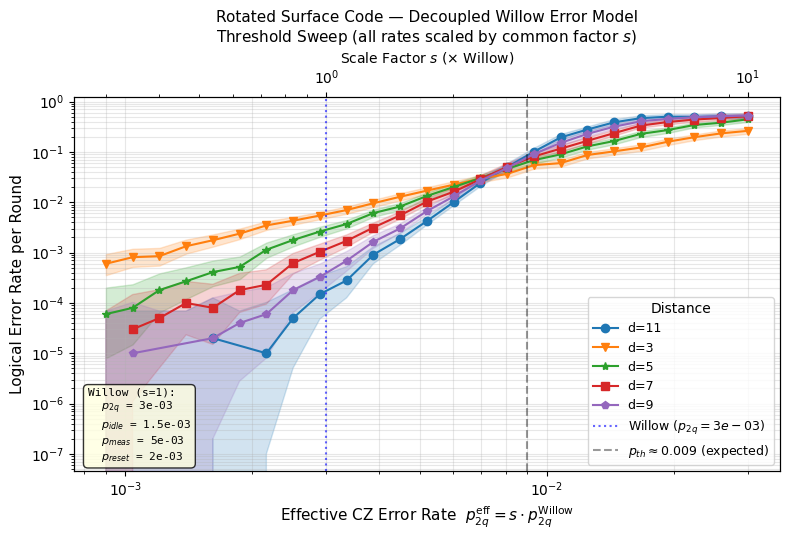

In [6]:
import os
os.makedirs("results", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5.5))

# Plot logical error rate vs effective p_2q
sinter.plot_error_rate(
    ax=ax,
    stats=results,
    x_func=lambda stat: stat.json_metadata['p_2q_eff'],
    group_func=lambda stat: f"d={stat.json_metadata['d']}",
    failure_units_per_shot_func=lambda stat: 1,
)

# Mark Willow operating point
ax.axvline(x=WILLOW['p_2q'], color='blue', linestyle=':', alpha=0.6, label=f"Willow ($p_{{2q}}={WILLOW['p_2q']:.0e}$)")
# Mark expected threshold
ax.axvline(x=0.009, color='k', linestyle='--', alpha=0.4, label=r"$p_{th} \approx 0.009$ (expected)")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Effective CZ Error Rate  $p_{2q}^{\\rm eff} = s \\cdot p_{2q}^{\\rm Willow}$', fontsize=11)
ax.set_ylabel('Logical Error Rate per Round', fontsize=11)
ax.set_title('Rotated Surface Code — Decoupled Willow Error Model\nThreshold Sweep (all rates scaled by common factor $s$)', fontsize=11)
ax.legend(title='Distance', fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Add secondary axis for scale factor
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(np.array(ax.get_xlim()) / WILLOW['p_2q'])
ax2.set_xlabel('Scale Factor $s$ (× Willow)', fontsize=10)

# Annotation box with Willow parameters
param_text = '\n'.join([
    'Willow (s=1):',
    f"  $p_{{2q}}$ = {WILLOW['p_2q']:.0e}",
    f"  $p_{{idle}}$ = {WILLOW['p_idle']:.1e}",
    f"  $p_{{meas}}$ = {WILLOW['p_meas']:.0e}",
    f"  $p_{{reset}}$ = {WILLOW['p_reset']:.0e}",
])
ax.text(
    0.02, 0.02, param_text, transform=ax.transAxes,
    fontsize=8, verticalalignment='bottom',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8),
    family='monospace',
)

plt.tight_layout()
plt.savefig('results/willow_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-channel sensitivity analysis

Fix all rates at Willow, then sweep **one channel at a time** to see which error source
dominates the logical error rate. This validates the Willow Fig 2c error budget hierarchy:
CZ gates > data idle > measurement > reset.

For each sweep, we fix d=7 (Willow's operating distance) and vary one rate from 
$10^{-4}$ to $5 \times 10^{-2}$ while holding the others at their Willow values.

In [7]:
d_sens = 7
sweep_values = np.logspace(-4, np.log10(0.05), 20)
shots_sens = 50_000

channels = {
    'p_2q':   {'label': 'CZ gate ($p_{2q}$)',   'color': 'black'},
    'p_idle': {'label': 'Data idle ($p_{idle}$)', 'color': 'goldenrod'},
    'p_meas': {'label': 'Measurement ($p_{meas}$)', 'color': 'blue'},
    'p_reset':{'label': 'Reset ($p_{reset}$)',    'color': 'red'},
}

sensitivity_tasks = []
for ch_name in channels:
    for val in sweep_values:
        params = {k: WILLOW[k] for k in ['p_2q', 'p_idle', 'p_meas', 'p_reset']}
        params[ch_name] = val
        circuit = make_willow_surface_code(d_sens, **params)
        sensitivity_tasks.append(sinter.Task(
            circuit=circuit,
            json_metadata={'channel': ch_name, 'val': float(val), 'd': d_sens},
        ))

print(f"{len(sensitivity_tasks)} tasks ({len(channels)} channels × {len(sweep_values)} values)")

sensitivity_results = sinter.collect(
    tasks=sensitivity_tasks,
    num_workers=4,
    max_shots=shots_sens,
    max_errors=200,
    decoders=['pymatching'],
    print_progress=True,
)

Starting 4 workers...


80 tasks (4 channels × 20 values)


80 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                                
        1 pymatching <1m      48703         200 channel=p_2q,val=0.0001,d=7                  
        1 pymatching   ?      50000         200 channel=p_2q,val=0.00013869188565300287,d=7  
        1 pymatching   ?      50000         200 channel=p_2q,val=0.000192354391459856,d=7    
        1 pymatching   ?      50000         200 channel=p_2q,val=0.0002667799326520327,d=7   
        0 pymatching ?·∞      50000         200 channel=p_2q,val=0.0003700021191389153,d=7   
        0 pymatching ?·∞      50000         200 channel=p_2q,val=0.0005131629159898318,d=7   
        0 pymatching ?·∞      50000         200 channel=p_2q,val=0.000711715324658232,d=7    
        0 pymatching ?·∞      50000         200 channel=p_2q,val=0.000987091404249892,d=7    
        0 pymatching ?·∞      50000         200 channel=p_2q,val=0.0013690156816728806,d=7   
        0 pymatching ?·∞      50000         2

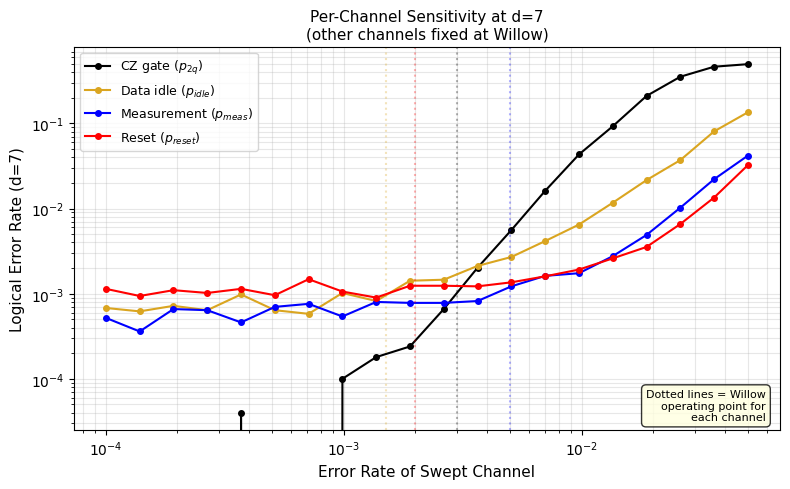

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for ch_name, ch_info in channels.items():
    ch_stats = [s for s in sensitivity_results if s.json_metadata['channel'] == ch_name]
    ch_stats.sort(key=lambda s: s.json_metadata['val'])
    
    vals = [s.json_metadata['val'] for s in ch_stats]
    rates = [s.errors / s.shots if s.shots > 0 else 0 for s in ch_stats]
    
    ax.plot(vals, rates, 'o-', color=ch_info['color'], label=ch_info['label'],
            markersize=4, linewidth=1.5)
    
    # Mark Willow operating point for this channel
    willow_val = WILLOW[ch_name]
    ax.axvline(x=willow_val, color=ch_info['color'], linestyle=':', alpha=0.3)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Error Rate of Swept Channel', fontsize=11)
ax.set_ylabel(f'Logical Error Rate (d={d_sens})', fontsize=11)
ax.set_title(f'Per-Channel Sensitivity at d={d_sens}\n(other channels fixed at Willow)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

ax.text(
    0.98, 0.02,
    'Dotted lines = Willow\noperating point for\neach channel',
    transform=ax.transAxes, fontsize=8,
    verticalalignment='bottom', horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8),
)

plt.tight_layout()
plt.savefig('results/willow_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Lambda extraction at Willow operating point

Compute the error suppression factor $\Lambda = \varepsilon_{d-2} / \varepsilon_d$ for consecutive distances.
Willow reports $\Lambda = 2.14 \pm 0.02$ at d=7 with a neural-net decoder; MWPM should give a 
somewhat lower value.

In [9]:
distances_lambda = [3, 5, 7, 9, 11]
shots_lambda = 200_000

print("Lambda extraction at Willow operating point (MWPM decoder)\n")

error_rates_by_d = {}
for d in distances_lambda:
    circuit = make_willow_surface_code(d)
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots_lambda, separate_observables=True)
    predictions = matcher.decode_batch(det_events)
    n_errors = np.sum(predictions != obs_flips)
    rate = n_errors / shots_lambda
    error_rates_by_d[d] = rate
    print(f"  d={d:2d}: ε = {rate:.6f}  ({n_errors}/{shots_lambda})")

print(f"\nError suppression ratios:")
for i in range(1, len(distances_lambda)):
    d_prev = distances_lambda[i-1]
    d_curr = distances_lambda[i]
    eps_prev = error_rates_by_d[d_prev]
    eps_curr = error_rates_by_d[d_curr]
    if eps_curr > 0:
        lam = eps_prev / eps_curr
        print(f"  Λ(d={d_prev}→{d_curr}) = ε_{d_prev}/ε_{d_curr} = {eps_prev:.5f}/{eps_curr:.5f} = {lam:.2f}")
    else:
        print(f"  Λ(d={d_prev}→{d_curr}) = ε_{d_prev}/ε_{d_curr} — no errors at d={d_curr}")

print(f"\nWillow reports Λ = 2.14 ± 0.02 (neural-net decoder, d=3→7)")
print(f"MWPM is suboptimal → expect Λ somewhat lower here.")

Lambda extraction at Willow operating point (MWPM decoder)

  d= 3: ε = 0.006135  (1227/200000)
  d= 5: ε = 0.002920  (584/200000)
  d= 7: ε = 0.001035  (207/200000)
  d= 9: ε = 0.000385  (77/200000)
  d=11: ε = 0.000155  (31/200000)

Error suppression ratios:
  Λ(d=3→5) = ε_3/ε_5 = 0.00613/0.00292 = 2.10
  Λ(d=5→7) = ε_5/ε_7 = 0.00292/0.00103 = 2.82
  Λ(d=7→9) = ε_7/ε_9 = 0.00103/0.00038 = 2.69
  Λ(d=9→11) = ε_9/ε_11 = 0.00038/0.00015 = 2.48

Willow reports Λ = 2.14 ± 0.02 (neural-net decoder, d=3→7)
MWPM is suboptimal → expect Λ somewhat lower here.


---
## Summary & next steps

**What this notebook establishes:**
1. Decoupled error model with independent rates for each operation type
2. Threshold sweep confirms $p_{th} \approx 0.009$ (consistent with baseline)
3. Per-channel sensitivity confirms CZ gate error dominates, matching Willow Fig 2c
4. $\Lambda$ extraction at Willow operating point (MWPM baseline)

**Next: 2.5D extension** (`2_5d_sensitivity.ipynb`)
- Add load/store errors (`DEPOLARIZE1(p_ls)`) around syndrome extraction
- Add memory qubit idle errors (`PAULI_CHANNEL_1` from T1/T2 of cavity)
- Sweep p_ls and T1_memory independently while fixing standard ops at Willow
- Find maximum tolerable p_ls and minimum required cavity T1